In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.cluster import KMeans
import networkx as nx
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 150,
    'font.family': 'sans-serif',
    'font.size': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.labelsize': 10,
    'axes.titlesize': 11,
    'axes.titleweight': 'normal',
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
})

BLUE   = '#2a78d6'
GREEN  = '#1baf7a'
PURPLE = '#4a3aa7'
RED    = '#e34948'
AMBER  = '#eda100'
GREY   = '#73726c'

FIG_PATH = r'C:\Users\namra\gluten-free-spatial-inequality\outputs\figures'
TAB_PATH = r'C:\Users\namra\gluten-free-spatial-inequality\outputs\tables'

df = pd.read_csv(r'C:\Users\namra\gluten-free-spatial-inequality\data\processed\analytical_dataset_final.csv')

# Three axes for Ball Mapper
variables = ['prescribing_rate_recent', 'retail_accessibility_score', 'imd_score_weighted']
labels    = ['Recent prescribing rate', 'Retail accessibility', 'Weighted IMD score']

X_raw    = df[variables].values
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

print(f"Point cloud: {X_scaled.shape}")
print(f"\nRaw ranges:")
for v, l in zip(variables, labels):
    print(f"  {l}: {df[v].min():.3f} – {df[v].max():.3f}")
print(f"\nScaled ranges:")
for i, l in enumerate(labels):
    print(f"  {l}: {X_scaled[:,i].min():.3f} – {X_scaled[:,i].max():.3f}")

Point cloud: (106, 3)

Raw ranges:
  Recent prescribing rate: 0.000 – 28.161
  Retail accessibility: 0.170 – 0.424
  Weighted IMD score: 10.132 – 43.467

Scaled ranges:
  Recent prescribing rate: -0.960 – 2.365
  Retail accessibility: -2.048 – 2.627
  Weighted IMD score: -1.700 – 2.756


In [15]:
# ── CELL 2: BALL MAPPER ALGORITHM ─────────────────────────────────────────
# Implementation following Dlotko (2019) and Dlotko, Qiu and Rudkin (2022)

def ball_mapper(X, epsilon):
    """
    Ball Mapper algorithm.
    
    Covers a point cloud X with overlapping balls of radius epsilon.
    Each ball containing at least one point becomes a graph node.
    Two nodes are connected by an edge if their balls share any points.
    
    Parameters
    ----------
    X       : np.ndarray, shape (n, d) — standardised point cloud
    epsilon : float — ball radius governing graph resolution
    
    Returns
    -------
    nodes : dict {node_id: list of point indices}
    edges : list of (node_i, node_j) tuples
    """
    n = X.shape[0]
    dist = euclidean_distances(X)
    covered = np.zeros(n, dtype=bool)
    nodes = {}
    nid = 0

    for i in range(n):
        if not covered[i]:
            members = np.where(dist[i] <= epsilon)[0].tolist()
            nodes[nid] = members
            for j in members:
                covered[j] = True
            nid += 1

    edges = []
    ids = list(nodes.keys())
    for a in range(len(ids)):
        for b in range(a + 1, len(ids)):
            if set(nodes[ids[a]]) & set(nodes[ids[b]]):
                edges.append((ids[a], ids[b]))

    return nodes, edges


def node_mean(nodes, df, col):
    """Mean value of column col across members of each node."""
    return {nid: df[col].iloc[members].mean()
            for nid, members in nodes.items()}


def node_count(nodes):
    return {nid: len(members) for nid, members in nodes.items()}


print("Ball Mapper algorithm defined.")
print("Functions available: ball_mapper(), node_mean(), node_count()")

Ball Mapper algorithm defined.
Functions available: ball_mapper(), node_mean(), node_count()


 Epsilon   Nodes   Edges   Connected   Components   Avg size
------------------------------------------------------------
    0.50      59      18       False           45        2.2
    0.75      38      26       False           19        3.8
    1.00      29      46       False            5        6.4
    1.25      17      24       False            2        9.6
    1.50      12      20       False            2       15.7
    1.75       9      12       False            2       18.3
    2.00       7      11        True            1       25.7
    2.50       6      14        True            1       43.3
    3.00       4       6        True            1       68.8


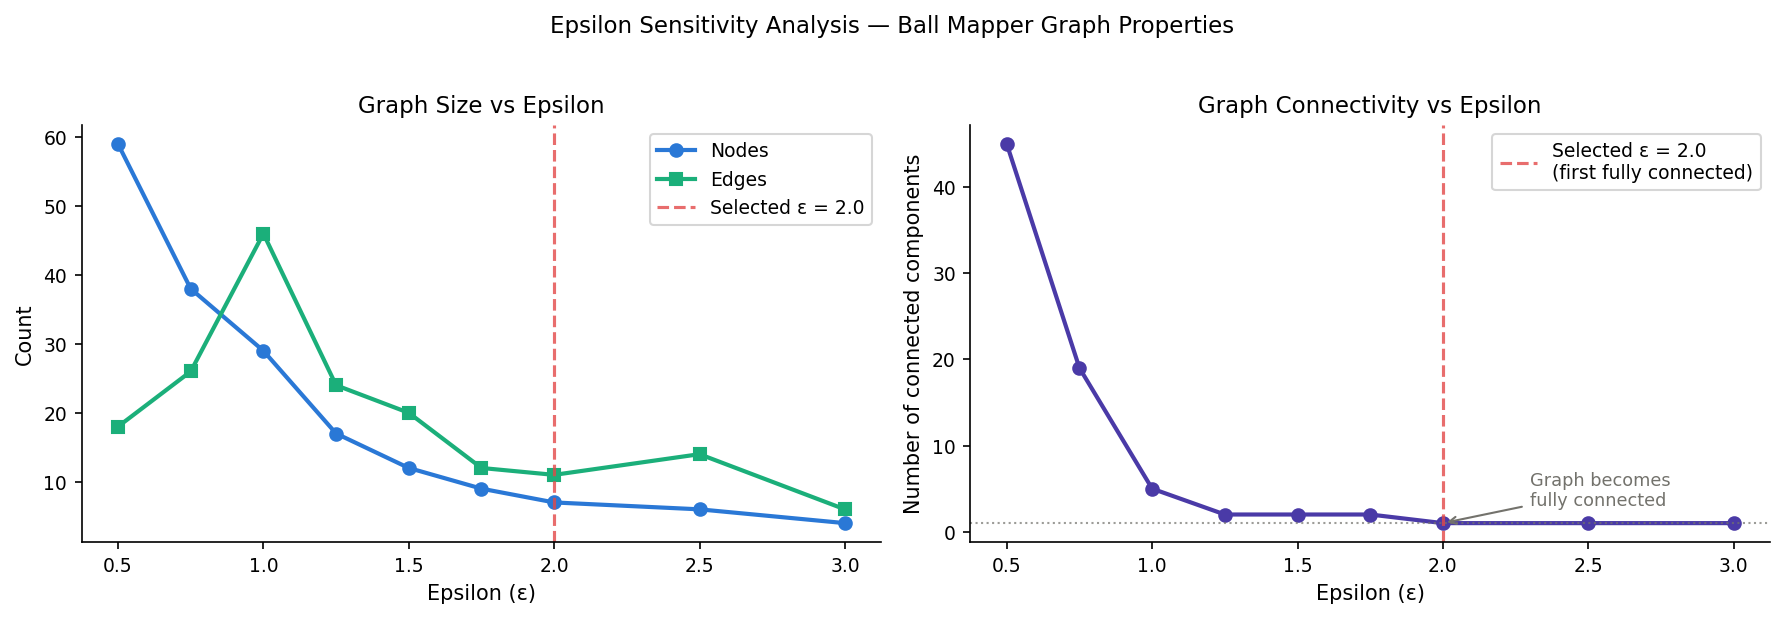

Saved BM_01.


In [16]:
# ── CELL 3: EPSILON SENSITIVITY ANALYSIS ──────────────────────────────────
# Following Dlotko and Rudkin (2020): select smallest epsilon
# at which the graph becomes fully connected

epsilons = [0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.5, 3.0]
results = []

print(f"{'Epsilon':>8} {'Nodes':>7} {'Edges':>7} {'Connected':>11} "
      f"{'Components':>12} {'Avg size':>10}")
print("-" * 60)

for eps in epsilons:
    nodes_e, edges_e = ball_mapper(X_scaled, eps)
    G_e = nx.Graph()
    G_e.add_nodes_from(nodes_e.keys())
    G_e.add_edges_from(edges_e)
    n_comp = nx.number_connected_components(G_e)
    connected = nx.is_connected(G_e)
    avg_sz = np.mean([len(v) for v in nodes_e.values()])
    results.append({'epsilon': eps, 'nodes': len(nodes_e),
                    'edges': len(edges_e), 'connected': connected,
                    'components': n_comp, 'avg_size': avg_sz})
    print(f"{eps:>8.2f} {len(nodes_e):>7} {len(edges_e):>7} "
          f"{str(connected):>11} {n_comp:>12} {avg_sz:>10.1f}")

# Plot sensitivity curve
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

eps_vals = [r['epsilon'] for r in results]
nodes_vals = [r['nodes'] for r in results]
edges_vals = [r['edges'] for r in results]
comp_vals = [r['components'] for r in results]

axes[0].plot(eps_vals, nodes_vals, color=BLUE, marker='o',
             linewidth=2, markersize=6, label='Nodes')
axes[0].plot(eps_vals, edges_vals, color=GREEN, marker='s',
             linewidth=2, markersize=6, label='Edges')
axes[0].axvline(2.0, color=RED, linewidth=1.5, linestyle='--',
                alpha=0.8, label='Selected ε = 2.0')
axes[0].set_xlabel('Epsilon (ε)')
axes[0].set_ylabel('Count')
axes[0].set_title('Graph Size vs Epsilon')
axes[0].legend()

axes[1].plot(eps_vals, comp_vals, color=PURPLE, marker='o',
             linewidth=2, markersize=6)
axes[1].axhline(1, color=GREY, linewidth=1, linestyle=':', alpha=0.7)
axes[1].axvline(2.0, color=RED, linewidth=1.5, linestyle='--',
                alpha=0.8, label='Selected ε = 2.0\n(first fully connected)')
axes[1].set_xlabel('Epsilon (ε)')
axes[1].set_ylabel('Number of connected components')
axes[1].set_title('Graph Connectivity vs Epsilon')
axes[1].legend()
axes[1].annotate('Graph becomes\nfully connected', 
                 xy=(2.0, 1), xytext=(2.3, 3),
                 arrowprops=dict(arrowstyle='->', color=GREY, lw=1),
                 fontsize=8.5, color=GREY)

plt.suptitle('Epsilon Sensitivity Analysis — Ball Mapper Graph Properties',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(f'{FIG_PATH}/BM_01_epsilon_sensitivity.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("Saved BM_01.")

In [17]:
# ── CELL 4: BUILD BALL MAPPER AT SELECTED EPSILON ─────────────────────────

EPSILON = 2.0
nodes, edges = ball_mapper(X_scaled, EPSILON)

G = nx.Graph()
G.add_nodes_from(nodes.keys())
G.add_edges_from(edges)

# Fix layout seed for reproducibility
pos = nx.spring_layout(G, seed=42, k=2.5)

# Compute node properties
n_size    = node_count(nodes)
n_presc   = node_mean(nodes, df, 'prescribing_rate_recent')
n_retail  = node_mean(nodes, df, 'retail_accessibility_score')
n_imd     = node_mean(nodes, df, 'imd_score_weighted')
n_months  = node_mean(nodes, df, 'months_zero')
n_slope   = node_mean(nodes, df, 'trend_slope')

print(f"Ball Mapper at ε = {EPSILON}")
print(f"Nodes: {len(nodes)} | Edges: {len(edges)} | "
      f"Connected: {nx.is_connected(G)}")
print(f"\n{'Node':>5} {'Areas':>6} {'Prescribing':>12} "
      f"{'Retail':>8} {'IMD':>7} {'Mths zero':>10} {'Trend':>8}")
print("-" * 60)
for nid in sorted(nodes.keys()):
    print(f"  N{nid}   {n_size[nid]:>5}   {n_presc[nid]:>10.1f}   "
          f"{n_retail[nid]:>7.3f}   {n_imd[nid]:>6.1f}   "
          f"{n_months[nid]:>8.1f}   {n_slope[nid]:>7.4f}")

Ball Mapper at ε = 2.0
Nodes: 7 | Edges: 11 | Connected: True

 Node  Areas  Prescribing   Retail     IMD  Mths zero    Trend
------------------------------------------------------------
  N0      44         15.2     0.287     23.1        0.1    0.0162
  N1      23          3.1     0.277     30.2       10.0   -0.0934
  N2      60          3.6     0.285     19.2        4.4   -0.0462
  N3       5         20.6     0.352     33.1        0.0    0.0670
  N4       9          3.6     0.376     15.8        2.6    0.0000
  N5      16         18.1     0.239     31.6        0.2    0.0140
  N6      23          2.6     0.232     19.2        3.4   -0.0292


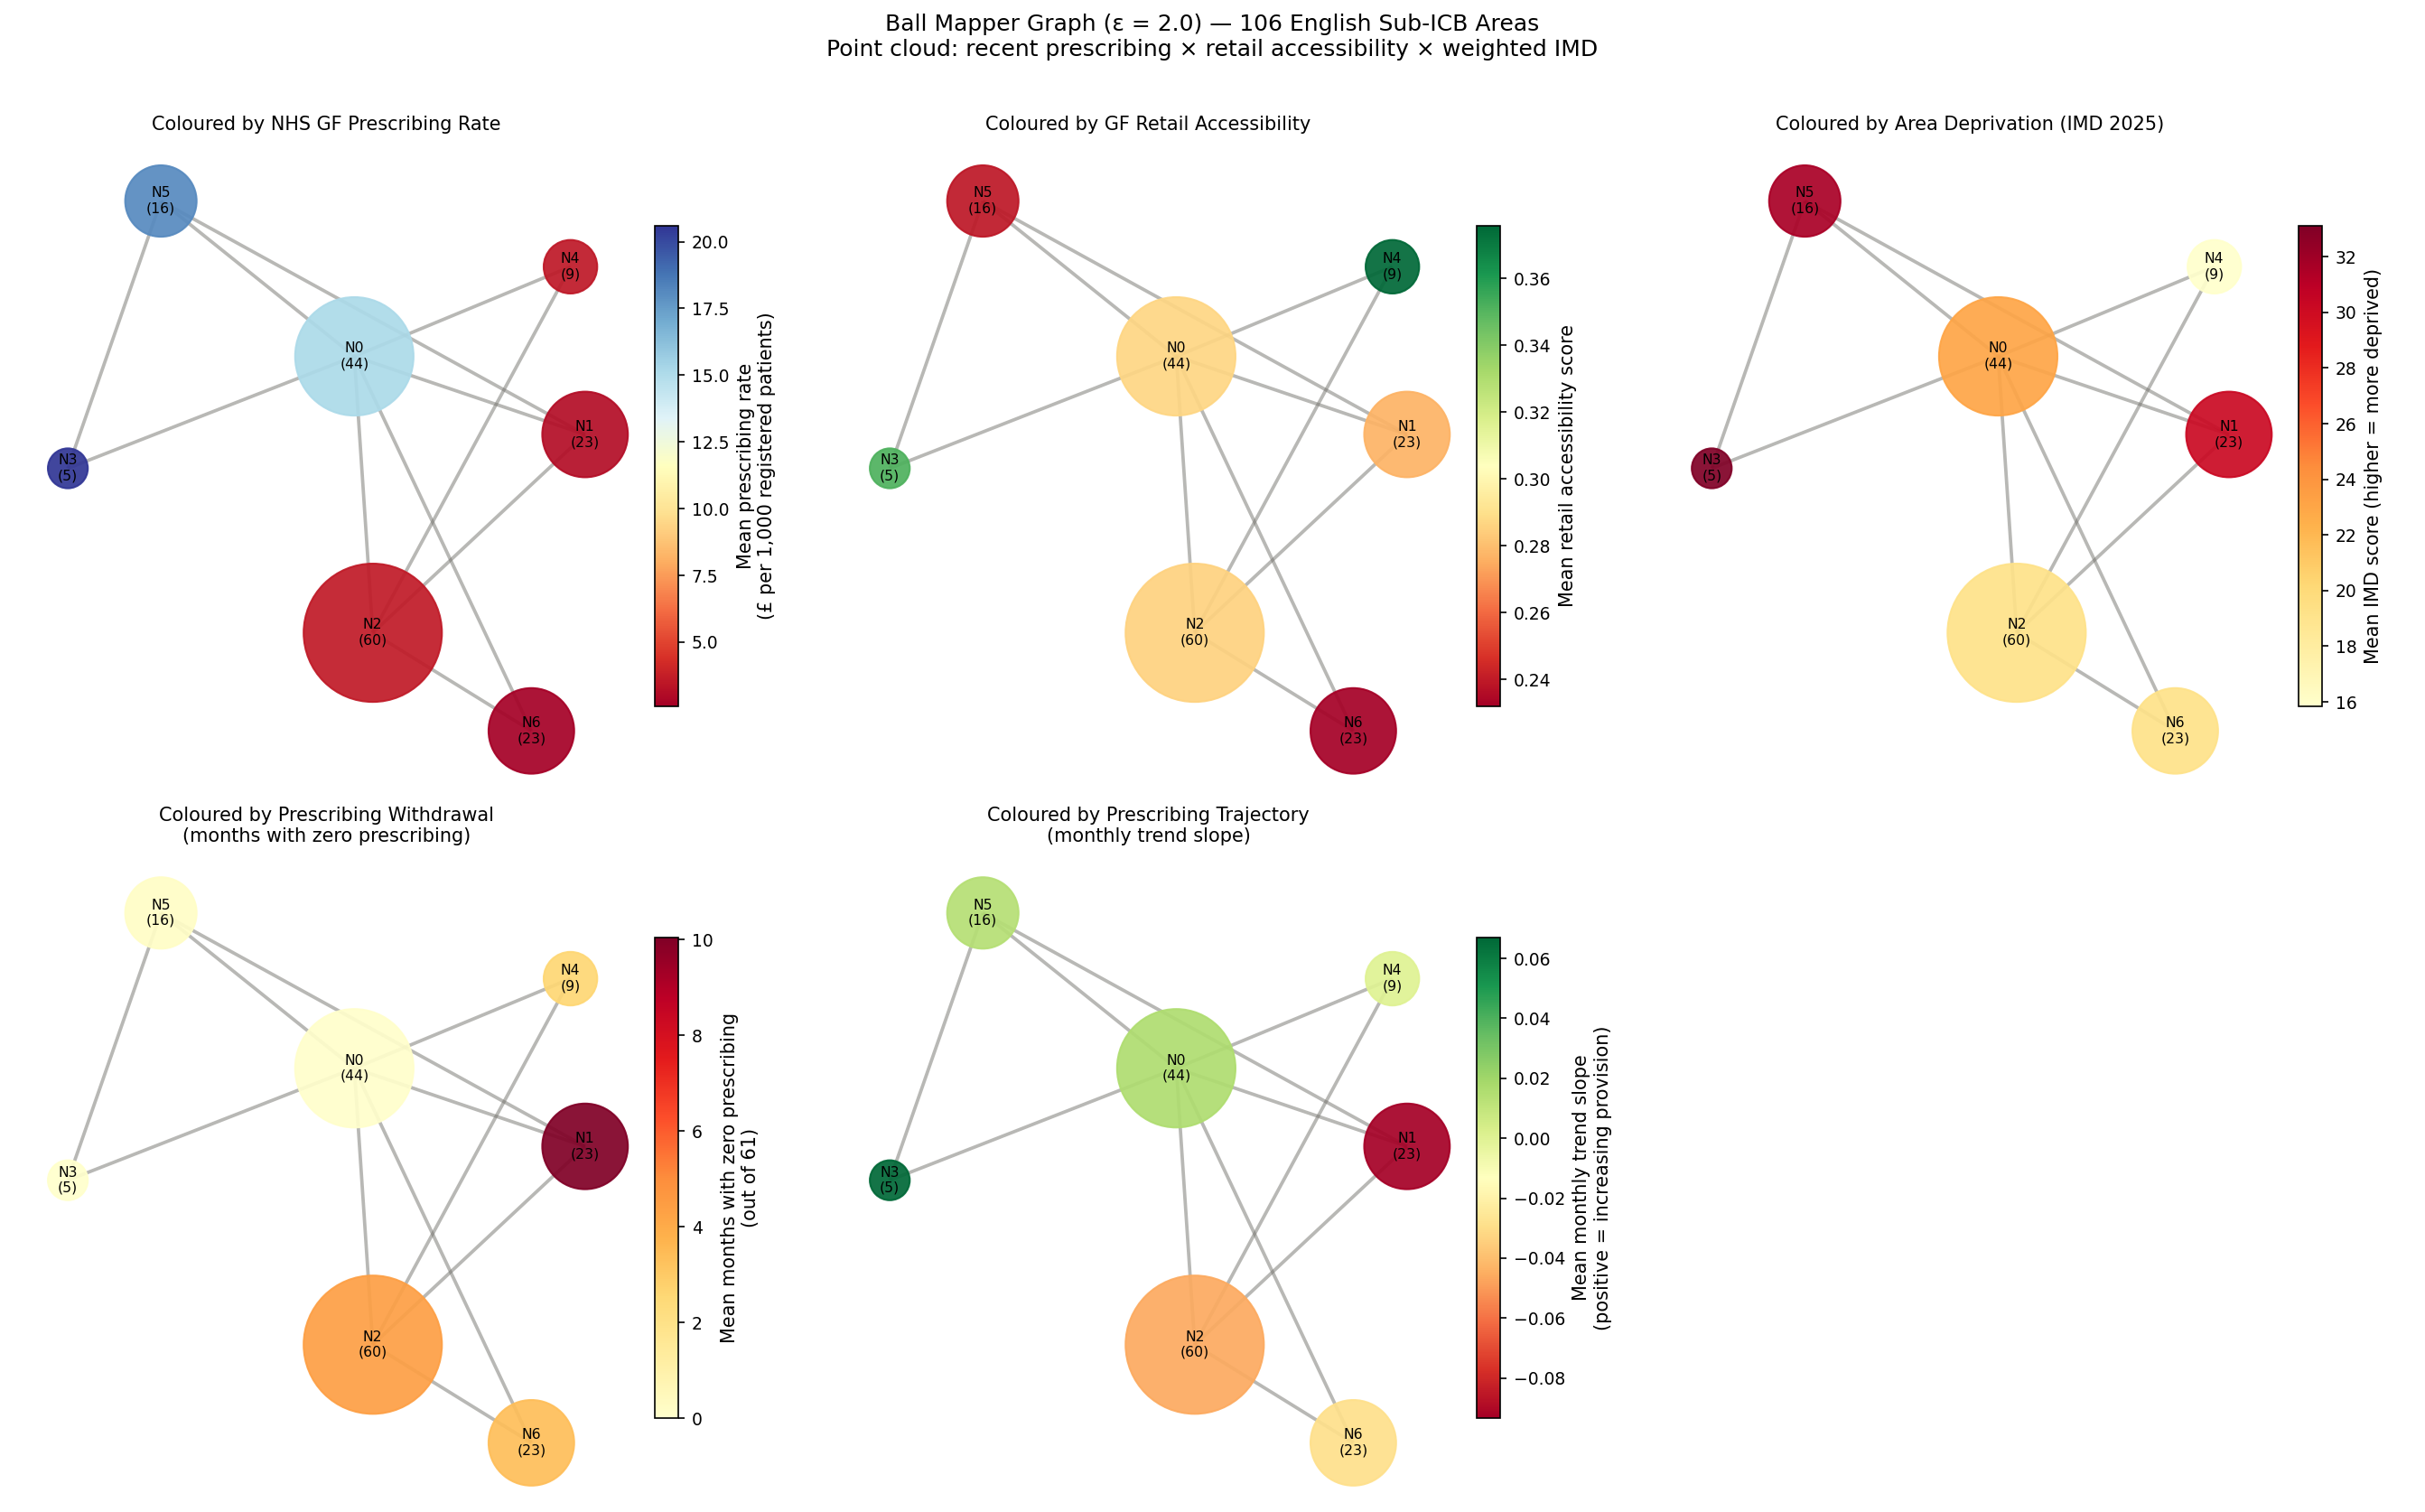

Saved BM_02.


In [18]:
# ── CELL 5: BALL MAPPER VISUALISATION — FIVE COLOURED PANELS ──────────────

def draw_bm(ax, G, pos, node_vals, node_sizes, cmap, vmin, vmax,
            title, cbar_label, fig):
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
    colors = [cmap(norm(node_vals[n])) for n in G.nodes()]
    sizes  = [node_sizes[n] * 90 for n in G.nodes()]

    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=sizes,
                           node_color=colors, alpha=0.92)
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color=GREY,
                           width=1.8, alpha=0.5)
    nx.draw_networkx_labels(G, pos, ax=ax,
                            labels={n: f"N{n}\n({node_sizes[n]})"
                                    for n in G.nodes()},
                            font_size=7.5, font_color='black')
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    plt.colorbar(sm, ax=ax, shrink=0.75, label=cbar_label, pad=0.02)
    ax.set_title(title, fontsize=10, pad=8)
    ax.axis('off')

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

panels = [
    (n_presc,  plt.cm.RdYlBu,
     'Coloured by NHS GF Prescribing Rate',
     'Mean prescribing rate\n(£ per 1,000 registered patients)'),
    (n_retail, plt.cm.RdYlGn,
     'Coloured by GF Retail Accessibility',
     'Mean retail accessibility score'),
    (n_imd,    plt.cm.YlOrRd,
     'Coloured by Area Deprivation (IMD 2025)',
     'Mean IMD score (higher = more deprived)'),
    (n_months, plt.cm.YlOrRd,
     'Coloured by Prescribing Withdrawal\n(months with zero prescribing)',
     'Mean months with zero prescribing\n(out of 61)'),
    (n_slope,  plt.cm.RdYlGn,
     'Coloured by Prescribing Trajectory\n(monthly trend slope)',
     'Mean monthly trend slope\n(positive = increasing provision)'),
]

for ax, (vals, cmap, title, cbar) in zip(axes[:5], panels):
    vmin = min(vals.values())
    vmax = max(vals.values())
    draw_bm(ax, G, pos, vals, n_size, cmap, vmin, vmax, title, cbar, fig)

# Turn off unused 6th panel
axes[5].axis('off')

fig.suptitle(
    f'Ball Mapper Graph (ε = {EPSILON}) — 106 English Sub-ICB Areas\n'
    f'Point cloud: recent prescribing × retail accessibility × weighted IMD',
    fontsize=12, fontweight='normal', y=1.01)

plt.tight_layout()
plt.savefig(f'{FIG_PATH}/BM_02_five_panels.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("Saved BM_02.")

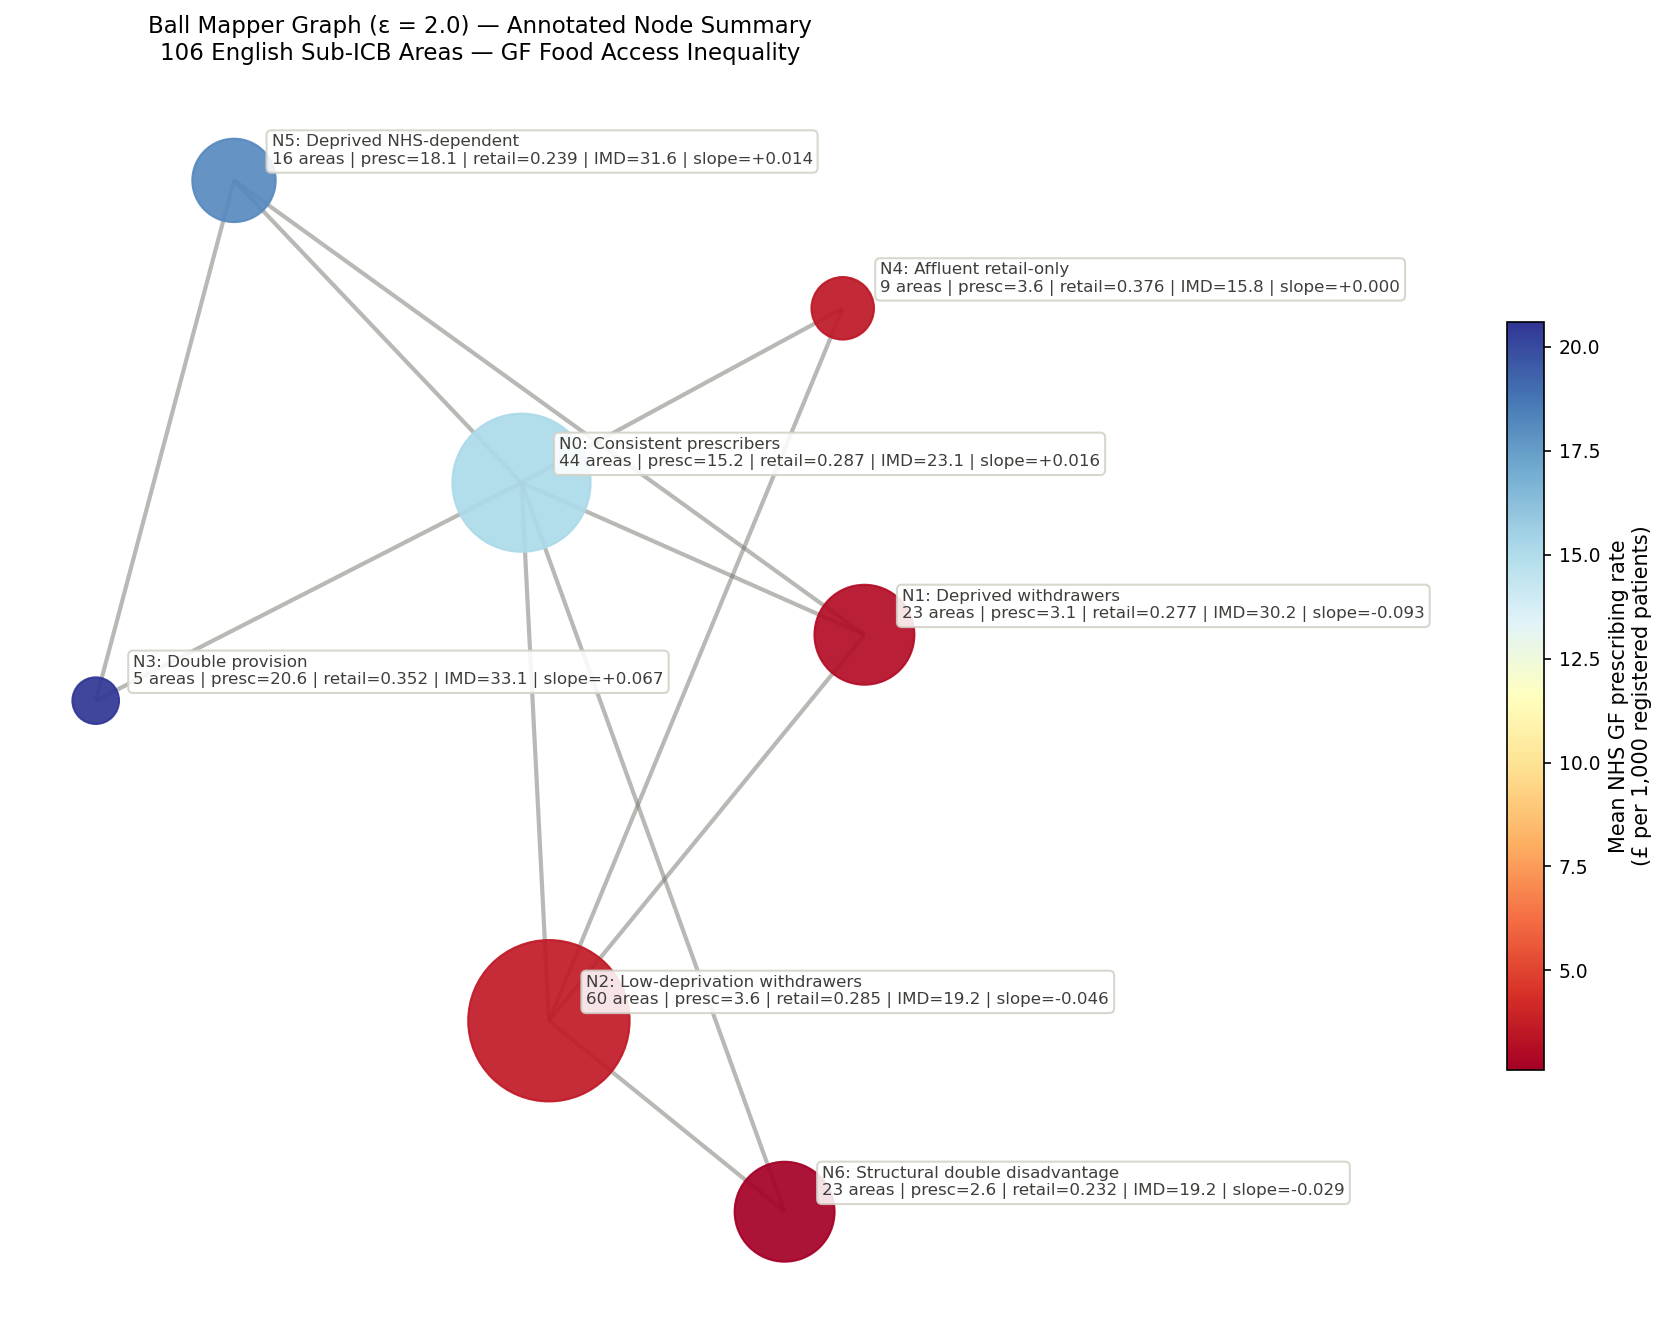

Saved BM_03.


In [19]:
# ── CELL 6: ANNOTATED GRAPH ───────────────────────────────────────────────

node_labels_dict = {
    0: 'Consistent prescribers',
    1: 'Deprived withdrawers',
    2: 'Low-deprivation withdrawers',
    3: 'Double provision',
    4: 'Affluent retail-only',
    5: 'Deprived NHS-dependent',
    6: 'Structural double disadvantage'
}

fig, ax = plt.subplots(figsize=(12, 9))

norm_p = mcolors.Normalize(vmin=min(n_presc.values()),
                            vmax=max(n_presc.values()))
colors_p = [plt.cm.RdYlBu(norm_p(n_presc[n])) for n in G.nodes()]
sizes_p  = [n_size[n] * 100 for n in G.nodes()]

nx.draw_networkx_nodes(G, pos, ax=ax, node_size=sizes_p,
                       node_color=colors_p, alpha=0.92)
nx.draw_networkx_edges(G, pos, ax=ax, edge_color=GREY,
                       width=2, alpha=0.5)

for n in G.nodes():
    x, y = pos[n]
    ax.annotate(
        f"N{n}: {node_labels_dict[n]}\n"
        f"{n_size[n]} areas | presc={n_presc[n]:.1f} | "
        f"retail={n_retail[n]:.3f} | IMD={n_imd[n]:.1f} | "
        f"slope={n_slope[n]:+.3f}",
        xy=(x, y), xytext=(18, 8), textcoords='offset points',
        fontsize=8, color='#3d3d3a',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                  edgecolor='#d3d1c7', alpha=0.88))

sm = plt.cm.ScalarMappable(cmap=plt.cm.RdYlBu, norm=norm_p)
sm.set_array([])
plt.colorbar(sm, ax=ax, shrink=0.6,
             label='Mean NHS GF prescribing rate\n(£ per 1,000 registered patients)',
             pad=0.32)

ax.set_title(
    f'Ball Mapper Graph (ε = {EPSILON}) — Annotated Node Summary\n'
    f'106 English Sub-ICB Areas — GF Food Access Inequality',
    fontsize=11, fontweight='normal')
ax.axis('off')
plt.tight_layout()
plt.savefig(f'{FIG_PATH}/BM_03_annotated.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved BM_03.")

In [21]:
def draw_bm(ax, G, pos, node_vals, node_sizes, cmap, vmin, vmax,
            title, cbar_label):
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
    colors = [cmap(norm(node_vals[n])) for n in G.nodes()]
    sizes  = [node_sizes[n] * 90 for n in G.nodes()]
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=sizes,
                           node_color=colors, alpha=0.92)
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color=GREY,
                           width=1.8, alpha=0.5)
    nx.draw_networkx_labels(G, pos, ax=ax,
                            labels={n: f"N{n}\n({node_sizes[n]})"
                                    for n in G.nodes()},
                            font_size=7.5, font_color='black')
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    plt.colorbar(sm, ax=ax, shrink=0.65, label=cbar_label, pad=0.08)
    ax.set_title(title, fontsize=10, pad=8)
    ax.axis('off')

print("draw_bm updated.")

draw_bm updated.


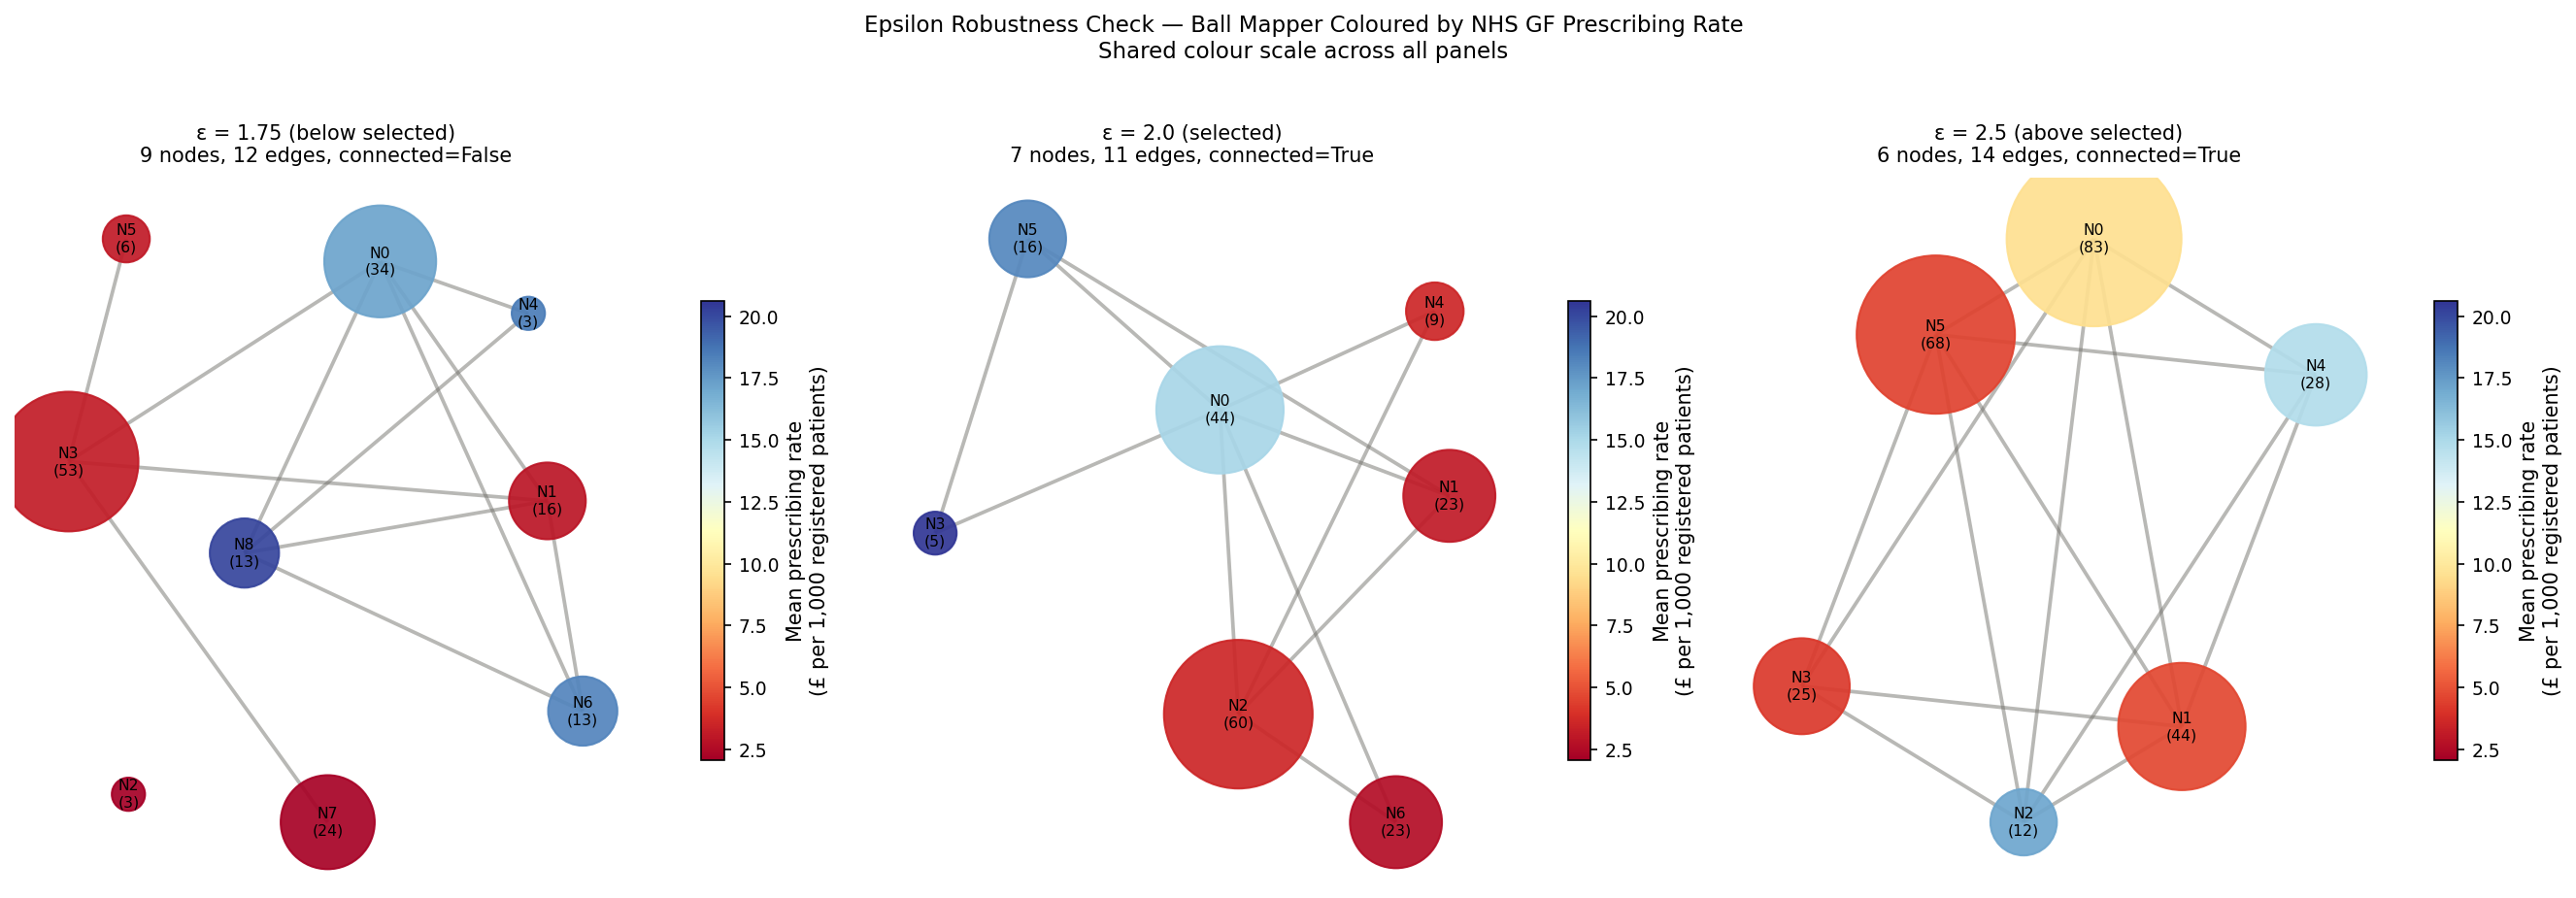

Saved BM_04.


In [23]:
# ── EPSILON ROBUSTNESS: BM at ε=1.75 and ε=2.5 coloured by prescribing ───

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

epsilons_rob = [1.75, 2.0, 2.5]
titles_rob = ['ε = 1.75 (below selected)',
              'ε = 2.0 (selected)',
              'ε = 2.5 (above selected)']

# Pre-compute all node prescribing values to get shared scale
all_presc_vals = []
graphs_rob = []
for eps in epsilons_rob:
    n_rob, e_rob = ball_mapper(X_scaled, eps)
    G_rob = nx.Graph()
    G_rob.add_nodes_from(n_rob.keys())
    G_rob.add_edges_from(e_rob)
    pos_rob = nx.spring_layout(G_rob, seed=42, k=2.5)
    n_presc_rob = node_mean(n_rob, df, 'prescribing_rate_recent')
    n_size_rob  = node_count(n_rob)
    connected   = nx.is_connected(G_rob)
    all_presc_vals.extend(n_presc_rob.values())
    graphs_rob.append((G_rob, pos_rob, n_presc_rob, n_size_rob,
                       len(n_rob), len(e_rob), connected))

# Shared colour scale across all three panels
vmin_shared = min(all_presc_vals)
vmax_shared = max(all_presc_vals)

for ax, (G_rob, pos_rob, n_presc_rob, n_size_rob,
          n_nodes, n_edges, connected), title in zip(axes, graphs_rob, titles_rob):
    draw_bm(ax, G_rob, pos_rob, n_presc_rob, n_size_rob,
            plt.cm.RdYlBu,
            vmin_shared, vmax_shared,
            f'{title}\n{n_nodes} nodes, {n_edges} edges, '
            f'connected={connected}',
            'Mean prescribing rate\n(£ per 1,000 registered patients)')

plt.suptitle('Epsilon Robustness Check — Ball Mapper Coloured by NHS GF Prescribing Rate\n'
             'Shared colour scale across all panels',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(f'{FIG_PATH}/BM_04_epsilon_robustness.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved BM_04.")

In [24]:
from sklearn.metrics import adjusted_rand_score

def primary_node_partition(nodes, n_points):
    """Assign each point to the first node it appears in."""
    labels = np.full(n_points, -1)
    for nid, members in nodes.items():
        for m in members:
            if labels[m] == -1:
                labels[m] = nid
    return labels

n_points = len(df)

nodes_175, _ = ball_mapper(X_scaled, 1.75)
nodes_200, _ = ball_mapper(X_scaled, 2.00)
nodes_250, _ = ball_mapper(X_scaled, 2.50)

labels_175 = primary_node_partition(nodes_175, n_points)
labels_200 = primary_node_partition(nodes_200, n_points)
labels_250 = primary_node_partition(nodes_250, n_points)

ari_175_200 = adjusted_rand_score(labels_175, labels_200)
ari_200_250 = adjusted_rand_score(labels_200, labels_250)
ari_175_250 = adjusted_rand_score(labels_175, labels_250)

print(f"Adjusted Rand Index — epsilon robustness:")
print(f"  ε=1.75 vs ε=2.00 : ARI = {ari_175_200:.4f}")
print(f"  ε=2.00 vs ε=2.50 : ARI = {ari_200_250:.4f}")
print(f"  ε=1.75 vs ε=2.50 : ARI = {ari_175_250:.4f}")
print(f"\nARI interpretation: 1.0 = identical, 0.0 = random, >0.6 = strong agreement")

Adjusted Rand Index — epsilon robustness:
  ε=1.75 vs ε=2.00 : ARI = 0.6236
  ε=2.00 vs ε=2.50 : ARI = 0.1998
  ε=1.75 vs ε=2.50 : ARI = 0.1902

ARI interpretation: 1.0 = identical, 0.0 = random, >0.6 = strong agreement


In [25]:
# ── BINARY RETAIL ROBUSTNESS CHECK ────────────────────────────────────────
# Re-run Ball Mapper replacing three-tier retail score with binary weighting
# Binary: 0 = budget stores, 1 = non-budget (regular + quality)
# Tests whether the three-tier weighting scheme drives the results

df['retail_accessibility_binary'] = (
    (df['regular_stores'] + df['quality_stores']) / df['total_stores']
)

print("Binary retail score summary:")
print(df['retail_accessibility_binary'].describe().round(3))
print(f"\nCorrelation with original retail score: "
      f"{df['retail_accessibility_binary'].corr(df['retail_accessibility_score']):.4f}")

# Build new point cloud with binary retail
variables_bin = ['prescribing_rate_recent', 
                 'retail_accessibility_binary', 
                 'imd_score_weighted']
X_bin = StandardScaler().fit_transform(df[variables_bin].values)

# Run Ball Mapper at same epsilon
nodes_bin, edges_bin = ball_mapper(X_bin, EPSILON)
G_bin = nx.Graph()
G_bin.add_nodes_from(nodes_bin.keys())
G_bin.add_edges_from(edges_bin)
pos_bin = nx.spring_layout(G_bin, seed=42, k=2.5)

n_size_bin  = node_count(nodes_bin)
n_presc_bin = node_mean(nodes_bin, df, 'prescribing_rate_recent')
n_retail_bin = node_mean(nodes_bin, df, 'retail_accessibility_binary')
n_imd_bin   = node_mean(nodes_bin, df, 'imd_score_weighted')

print(f"\nBinary retail BM: {len(nodes_bin)} nodes, {len(edges_bin)} edges, "
      f"connected={nx.is_connected(G_bin)}")
print(f"\nNode summary:")
print(f"{'Node':>5} {'Areas':>6} {'Prescribing':>12} "
      f"{'Retail (bin)':>13} {'IMD':>7}")
print("-" * 50)
for nid in sorted(nodes_bin.keys()):
    print(f"  N{nid}   {n_size_bin[nid]:>5}   "
          f"{n_presc_bin[nid]:>10.1f}   "
          f"{n_retail_bin[nid]:>11.3f}   "
          f"{n_imd_bin[nid]:>6.1f}")

# ARI comparison with original partition
labels_orig = primary_node_partition(nodes, len(df))
labels_bin  = primary_node_partition(nodes_bin, len(df))
ari_bin = adjusted_rand_score(labels_orig, labels_bin)
print(f"\nARI original vs binary retail: {ari_bin:.4f}")

Binary retail score summary:
count    106.000
mean       0.238
std        0.043
min        0.149
25%        0.211
50%        0.231
75%        0.260
max        0.381
Name: retail_accessibility_binary, dtype: float64

Correlation with original retail score: 0.8691

Binary retail BM: 7 nodes, 10 edges, connected=False

Node summary:
 Node  Areas  Prescribing  Retail (bin)     IMD
--------------------------------------------------
  N0      46         15.1         0.243     22.9
  N1      23          3.8         0.243     29.3
  N2       5          4.2         0.194     35.6
  N3      60          3.3         0.241     19.2
  N4       2         19.9         0.378     33.3
  N5      18         18.0         0.226     31.4
  N6      38          2.4         0.209     18.1

ARI original vs binary retail: 0.8258


In [26]:
# Check connectivity at epsilon=2.5 for binary retail
nodes_bin25, edges_bin25 = ball_mapper(X_bin, 2.5)
G_bin25 = nx.Graph()
G_bin25.add_nodes_from(nodes_bin25.keys())
G_bin25.add_edges_from(edges_bin25)
print(f"Binary retail at ε=2.5: {len(nodes_bin25)} nodes, "
      f"{len(edges_bin25)} edges, connected={nx.is_connected(G_bin25)}")

nodes_bin175, edges_bin175 = ball_mapper(X_bin, 1.75)
G_bin175 = nx.Graph()
G_bin175.add_nodes_from(nodes_bin175.keys())
G_bin175.add_edges_from(edges_bin175)
print(f"Binary retail at ε=1.75: {len(nodes_bin175)} nodes, "
      f"{len(edges_bin175)} edges, connected={nx.is_connected(G_bin175)}")

# Also check ARI at epsilon=2.5
labels_bin25 = primary_node_partition(nodes_bin25, len(df))
ari_bin25 = adjusted_rand_score(labels_orig, labels_bin25)
print(f"\nARI original (ε=2.0) vs binary retail (ε=2.5): {ari_bin25:.4f}")

Binary retail at ε=2.5: 5 nodes, 8 edges, connected=True
Binary retail at ε=1.75: 11 nodes, 21 edges, connected=False

ARI original (ε=2.0) vs binary retail (ε=2.5): 0.1872


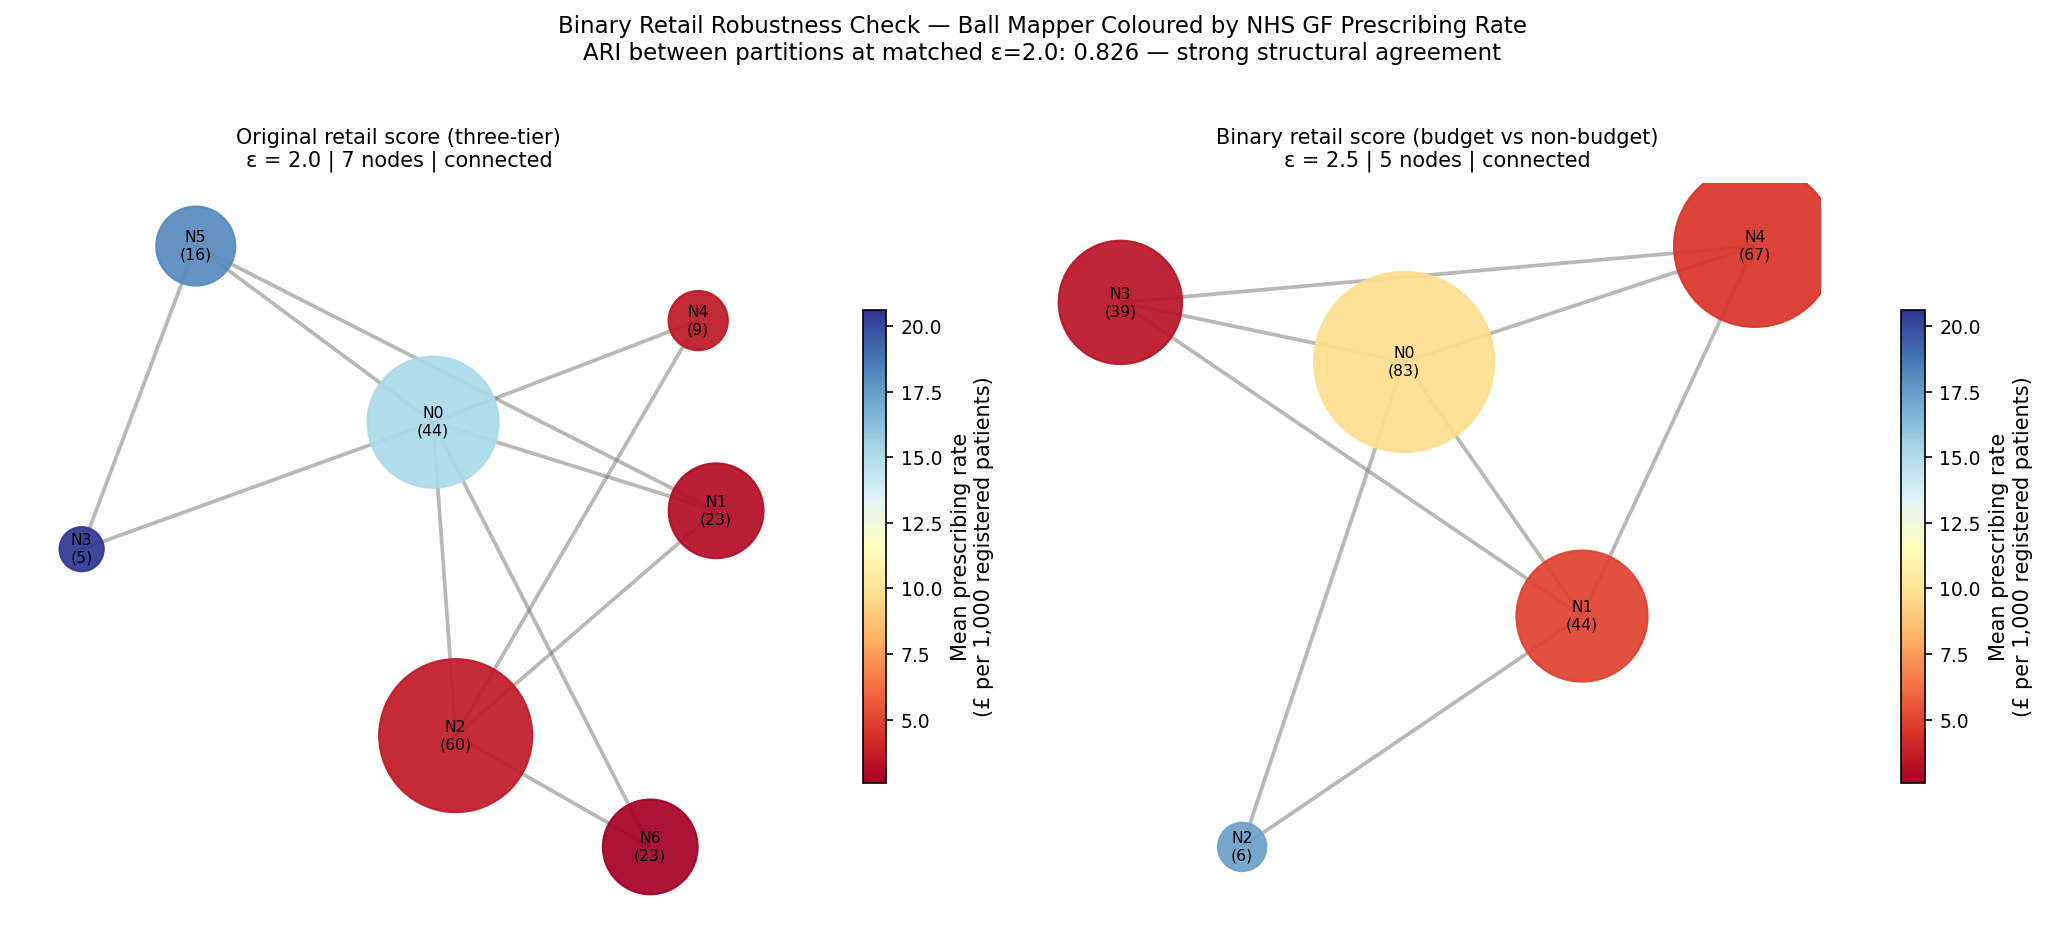

Saved BM_05.


In [27]:
# ── BINARY RETAIL ROBUSTNESS PLOT ─────────────────────────────────────────

pos_bin25 = nx.spring_layout(G_bin25, seed=42, k=2.5)
n_size_bin25  = node_count(nodes_bin25)
n_presc_bin25 = node_mean(nodes_bin25, df, 'prescribing_rate_recent')
n_imd_bin25   = node_mean(nodes_bin25, df, 'imd_score_weighted')

# Shared prescribing colour scale across both panels
vmin_p = min(list(n_presc.values()) + list(n_presc_bin25.values()))
vmax_p = max(list(n_presc.values()) + list(n_presc_bin25.values()))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

draw_bm(axes[0], G, pos, n_presc, n_size,
        plt.cm.RdYlBu, vmin_p, vmax_p,
        f'Original retail score (three-tier)\nε = 2.0 | 7 nodes | connected',
        'Mean prescribing rate\n(£ per 1,000 registered patients)')

draw_bm(axes[1], G_bin25, pos_bin25, n_presc_bin25, n_size_bin25,
        plt.cm.RdYlBu, vmin_p, vmax_p,
        f'Binary retail score (budget vs non-budget)\nε = 2.5 | 5 nodes | connected',
        'Mean prescribing rate\n(£ per 1,000 registered patients)')

plt.suptitle(
    'Binary Retail Robustness Check — Ball Mapper Coloured by NHS GF Prescribing Rate\n'
    f'ARI between partitions at matched ε=2.0: 0.826 — strong structural agreement',
    fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(f'{FIG_PATH}/BM_05_binary_retail_robustness.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("Saved BM_05.")


In [28]:
# ── NODE MEMBERSHIP TABLE ──────────────────────────────────────────────────

node_labels_dict = {
    0: 'Consistent prescribers',
    1: 'Deprived withdrawers',
    2: 'Low-deprivation withdrawers',
    3: 'Double provision',
    4: 'Affluent retail-only',
    5: 'Deprived NHS-dependent',
    6: 'Structural double disadvantage'
}

rows = []
for nid, members in nodes.items():
    for m in members:
        rows.append({
            'node_id': nid,
            'node_label': node_labels_dict[nid],
            'org_id': df['org_id'].iloc[m],
            'org_name': df['org_name'].iloc[m],
            'prescribing_rate_recent': round(df['prescribing_rate_recent'].iloc[m], 3),
            'retail_accessibility_score': round(df['retail_accessibility_score'].iloc[m], 3),
            'imd_score_weighted': round(df['imd_score_weighted'].iloc[m], 3),
            'months_zero': int(df['months_zero'].iloc[m]),
            'trend_slope': round(df['trend_slope'].iloc[m], 4),
        })

membership_df = pd.DataFrame(rows).sort_values(['node_id', 'prescribing_rate_recent'],
                                                ascending=[True, False])
membership_df.to_csv(f'{TAB_PATH}/BM_node_membership.csv', index=False)

# Summary table
summary = membership_df.groupby(['node_id', 'node_label']).agg(
    areas=('org_id', 'count'),
    mean_prescribing=('prescribing_rate_recent', 'mean'),
    mean_retail=('retail_accessibility_score', 'mean'),
    mean_imd=('imd_score_weighted', 'mean'),
    mean_months_zero=('months_zero', 'mean'),
    mean_slope=('trend_slope', 'mean')
).round(3).reset_index()

summary.to_csv(f'{TAB_PATH}/BM_node_summary.csv', index=False)
print("Saved node membership and summary tables.")
print(f"\nTotal membership rows: {len(membership_df)}")
print(f"(exceeds 106 because areas can belong to multiple overlapping balls)")
print(f"\nNode summary:")
print(summary.to_string(index=False))

Saved node membership and summary tables.

Total membership rows: 180
(exceeds 106 because areas can belong to multiple overlapping balls)

Node summary:
 node_id                     node_label  areas  mean_prescribing  mean_retail  mean_imd  mean_months_zero  mean_slope
       0         Consistent prescribers     44            15.166        0.287    23.090             0.068       0.016
       1           Deprived withdrawers     23             3.140        0.277    30.210            10.043      -0.093
       2    Low-deprivation withdrawers     60             3.593        0.285    19.163             4.417      -0.046
       3               Double provision      5            20.602        0.352    33.121             0.000       0.067
       4           Affluent retail-only      9             3.571        0.376    15.838             2.556       0.000
       5         Deprived NHS-dependent     16            18.120        0.239    31.632             0.188       0.014
       6 Structural 